# 批量归一化

## 反向传播中的问题
- 前面训练慢，后面训练快
  - 局部最优附近，梯度比较小
  - 链式法则使梯度累乘
  - 越靠前（数据侧）的层，被累乘的次数多，梯度小

<br>

- 前面一变化，后面都得变
  - 靠前的层提取底层特征
  - 靠后的层基于前面提取的特征做二次提取
  - 后层是依赖前层的

前面的层收敛很慢，每次后面的层都要不断跟进，导致训练慢，甚至不收敛。

## Batch Norm
固定小批量里的均值和方差
- $\mu_B = \cfrac{1}{m} \sum_{i=1}^{m} x_i$

- $\sigma_B^2 = \cfrac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2 + \epsilon$

$$ x_{i+1} = \gamma\cfrac{x_i - \mu_B}{\sigma_B} + \beta $$

## Batch Norm 层
- 可学习的参数为 $\gamma$ 和 $\beta$，分别用于微调方差和均值
- 作用位置
  - 全连接、卷积层的输入前
  - 全连接、卷积层的输出后，激活函数前
- 作用范围
  - 全连接层在特征维
  - 卷积层在通道维

## 解释
- 最初论文: 减少内部协变量转移
- 后续论文: 加入噪音控制模型复杂度

现在一般认为是，减均值导致随机偏移，除方差导致随机缩放，属于添加噪音。因此没必要和 dropout 混用。


## 实现


In [13]:
import torch
from torch import nn
from torchinfo import summary
import util

### 从零实现


batch_norm


In [2]:
def batch_norm(X: torch.Tensor,
               gamma: torch.Tensor, beta: torch.Tensor,
               moving_mean: torch.Tensor, moving_var: torch.Tensor,
               eps: float, momentum: float):
    """批量归一化
    :param X: 输入数据，形状为 (batch_size, num_features)
    :param gamma: 缩放参数，形状为 (num_features,)
    :param beta: 偏移参数，形状为 (num_features,)
    :param moving_mean: 移动平均的均值，形状为 (num_features,)
    :param moving_var: 移动平均的方差，形状为 (num_features,)
    :param eps: 防止除零的极小值
    :param momentum: 移动平均的动量
    :return: 批量归一化后的输出，形状为 (batch_size, num_features)
    """
    if not torch.is_grad_enabled(): # 预测模式
        # 用全局的移动均值和方差
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else: # 训练模式
        # 全连接层 2 阶，2d卷积层 4 阶
        assert len(X.shape) in (2, 4)
        # 全连接 (batch_size, num_features)
        if len(X.shape) == 2:
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        # 2d卷积 (batch_size, num_channels, height, width)
        else:
            # 在通道维度上求，其他维度都揉进去，但保持阶数
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # 更新移动平均
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta # 缩放和偏移
    # 返回归一化结果、移动平均的均值、方差
    return Y, moving_mean.data, moving_var.data

batch_norm 层


In [3]:
class BatchNorm(nn.Module):
    """批量归一化层
    :param num_features: 特征数
    :param num_dims: 特征维度，2表示全连接层，4表示卷积层
    :param eps: 防止除零的极小值
    :param momentum: 移动平均的动量
    """
    def __init__(self,
                 num_features: int, num_dims: int,
                 eps: float = 1e-5, momentum: float = 0.9):
        super().__init__()
        # 准备参数的形状
        if num_dims == 2: # 全连接层
            shape = (1, num_features)
        else: # 卷积层
            shape = (1, num_features, 1, 1)
        # 可学习的缩放参数 gamma 和偏移参数 beta
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # 初始化移动平均的均值和方差
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)
        self.eps = eps
        self.momentum = momentum

    def forward(self, X: torch.Tensor):
        """使用 batch_norm 函数进行批量归一化"""
        # 统一设备
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # 调用 batch_norm 函数
        Y, self.moving_mean, self.moving_var = batch_norm(X,
                                                          self.gamma, self.beta,
                                                          self.moving_mean, self.moving_var,
                                                          self.eps, self.momentum)
        return Y

batch norm 层应用于 LeNet


In [7]:
net = nn.Sequential(
    # 第一个卷积层后插入 batch norm 层
    nn.Conv2d(1, 6, kernel_size=5, padding=2), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    # 第二个卷积层后插入 batch norm 层
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    # 两个线性层都加入 batch norm 层
    nn.Linear(16 * 5 * 5, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10)
)

In [14]:
summary(net, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Conv2d: 1-1                            [1, 6, 28, 28]            156
├─BatchNorm: 1-2                         [1, 6, 28, 28]            12
├─Sigmoid: 1-3                           [1, 6, 28, 28]            --
├─AvgPool2d: 1-4                         [1, 6, 14, 14]            --
├─Conv2d: 1-5                            [1, 16, 10, 10]           2,416
├─BatchNorm: 1-6                         [1, 16, 10, 10]           32
├─Sigmoid: 1-7                           [1, 16, 10, 10]           --
├─AvgPool2d: 1-8                         [1, 16, 5, 5]             --
├─Flatten: 1-9                           [1, 400]                  --
├─Linear: 1-10                           [1, 120]                  48,120
├─BatchNorm: 1-11                        [1, 120]                  240
├─Sigmoid: 1-12                          [1, 120]                  --
├─Line

loss 0.258, train acc 0.904, test acc 0.879
41936.8 examples/sec on cuda:0


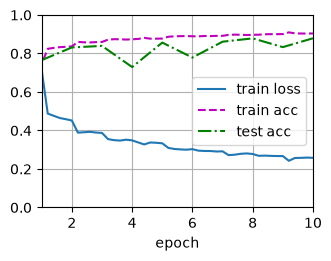

In [8]:
batch_size = 256
num_epochs = 10
lr = 1.0 # 加 batch norm 后可以用更大的学习率
train_iter, test_iter = util.data.load_data_fashion_mnist(batch_size=batch_size)
util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, util.try_gpu(), ylim=(0, 1))

In [16]:
torch.save(net.state_dict(), './models/LeNet-BN.pth')

查看第一个 bn 层学到的 gamma 和 beta 参数


In [11]:
net[1].gamma.reshape((-1,)).cpu().data, net[1].beta.reshape((-1,)).cpu().data

(tensor([2.2213, 2.7799, 2.8050, 3.3441, 4.1671, 1.0175]),
 tensor([ 2.2681, -0.6666, -2.3690, -0.6861,  2.2016,  1.3672]))

### 简洁实现


In [19]:
net = nn.Sequential(
    # 第一个卷积层后插入 BatchNorm2d 层
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    # 第二个卷积层后插入 BatchNorm2d 层
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    # 两个线性层都加入 BatchBorm1d 层
    nn.Linear(16 * 5 * 5, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

训练出来应该没什么区别


loss 0.243, train acc 0.911, test acc 0.853
79099.6 examples/sec on cuda:0


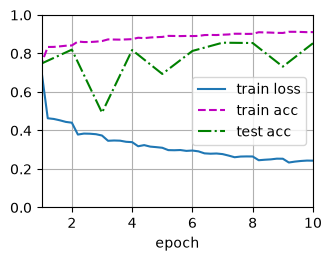

In [20]:
util.train.train_ch6(net, train_iter, test_iter, num_epochs, lr, util.try_gpu(), ylim=(0, 1))